# IEEE-CIS Fraud Detection with a Simple GNN (Step-by-Step Tutorial)

This notebook remakes the full tutorial using the Kaggle competition dataset:
https://www.kaggle.com/competitions/ieee-fraud-detection/data

You will learn how to:
1. Download and load IEEE-CIS data
2. Build a practical feature matrix from mixed tabular columns
3. Construct a k-nearest-neighbor transaction graph
4. Train a lightweight GCN-style model in PyTorch
5. Evaluate with ROC-AUC and PR-AUC
6. Experiment with settings for better performance

## Step 0: Environment setup

Run once in terminal:

```powershell
python -m venv .venv
. .venv/Scripts/Activate.ps1
pip install -r requirements.txt
pip install matplotlib
```

Optional but recommended: configure Kaggle API by placing `kaggle.json` in `%USERPROFILE%/.kaggle/kaggle.json`.

In [1]:
# Step 1: Imports
import random
import subprocess
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

In [6]:
# Step 2: Global config
DATA_DIR = Path('ieee-fraud-detection')  # local folder that already contains the CSV files
COMPETITION = 'ieee-fraud-detection'
MAX_ROWS = 60000       # lower this if your machine is slow
MAX_FEATURES = 120     # cap features to keep graph building manageable
K_NEIGHBORS = 8
HIDDEN_DIM = 64
DROPOUT = 0.20
EPOCHS = 30
LR = 1e-3
WEIGHT_DECAY = 1e-4
LOG_EVERY = 5
SEED = 42
FORCE_DOWNLOAD = False

In [3]:
# Step 3: Reproducibility helper
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(SEED)
print(f'Seed set to {SEED}')

Seed set to 42


## Step 4: Load IEEE-CIS training data

> Your data already exists in the local folder `ieee-fraud-detection`, so this notebook loads local files first.
> It only attempts Kaggle download if required files are missing.

We load:
- `train_transaction.csv`
- `train_identity.csv` (optional merge)

In [7]:
def maybe_download_ieee_cis(data_dir: Path, competition: str, force_download: bool = False) -> None:
    data_dir.mkdir(parents=True, exist_ok=True)

    tx_path = data_dir / 'train_transaction.csv'
    id_path = data_dir / 'train_identity.csv'
    files_ready = tx_path.exists() and id_path.exists()

    if files_ready and not force_download:
        print('[info] Using local IEEE-CIS files. Download skipped.')
        return

    cmd = [
        'kaggle',
        'competitions',
        'download',
        '-c',
        competition,
        '-p',
        str(data_dir),
        '--quiet',
    ]
    subprocess.run(cmd, check=True, capture_output=True, text=True)

    for zip_path in data_dir.glob('*.zip'):
        with zipfile.ZipFile(zip_path, 'r') as zf:
            zf.extractall(data_dir)


def load_ieee_cis_train(data_dir: Path) -> pd.DataFrame:
    tx_path = data_dir / 'train_transaction.csv'
    id_path = data_dir / 'train_identity.csv'

    if not tx_path.exists():
        raise FileNotFoundError(
            f'train_transaction.csv not found in {data_dir}. Check folder path or Kaggle download.'
        )

    tx_df = pd.read_csv(tx_path)
    if id_path.exists():
        id_df = pd.read_csv(id_path)
        df = tx_df.merge(id_df, on='TransactionID', how='left')
    else:
        df = tx_df

    return df


try:
    maybe_download_ieee_cis(DATA_DIR, COMPETITION, force_download=FORCE_DOWNLOAD)
    df_raw = load_ieee_cis_train(DATA_DIR)
    print(f'[info] Loaded rows={len(df_raw):,}, cols={df_raw.shape[1]:,} from {DATA_DIR}')
except Exception as ex:
    raise RuntimeError(
        'Unable to load IEEE-CIS data. Verify DATA_DIR or Kaggle credentials/access.'
    ) from ex

df_raw.head(3)

[info] Using local IEEE-CIS files. Download skipped.
[info] Loaded rows=590,540, cols=434 from ieee-fraud-detection


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 5: Understand target balance

`isFraud` is highly imbalanced, so we need imbalance-aware training and proper metrics.

Class counts (0=legit, 1=fraud):
isFraud
0    569877
1     20663
Name: count, dtype: int64
Fraud rate: 0.0350


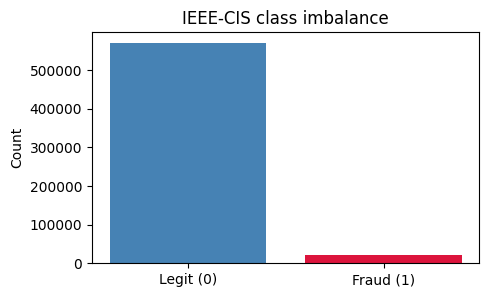

In [8]:
target_col = 'isFraud'
if target_col not in df_raw.columns:
    raise ValueError('Expected isFraud column in IEEE-CIS training data.')

class_counts = df_raw[target_col].value_counts().sort_index()
fraud_rate = float(df_raw[target_col].mean())
print('Class counts (0=legit, 1=fraud):')
print(class_counts)
print(f'Fraud rate: {fraud_rate:.4f}')

plt.figure(figsize=(5, 3))
plt.bar(['Legit (0)', 'Fraud (1)'], [class_counts.get(0, 0), class_counts.get(1, 0)], color=['steelblue', 'crimson'])
plt.title('IEEE-CIS class imbalance')
plt.ylabel('Count')
plt.show()

## Step 6: Feature preparation

For a practical first GNN baseline:
1. Subsample rows for speed
2. Remove leakage/id columns that are not useful graph signals
3. Fill missing values
4. Frequency-encode categorical columns
5. Keep top-variance numeric features and standardize

In [12]:
def prepare_ieee_features(
    df: pd.DataFrame, max_rows: int, max_features: int
 ) -> tuple[np.ndarray, np.ndarray, pd.Index, pd.DataFrame]:
    work_df = df.copy()

    if len(work_df) > max_rows:
        work_df = work_df.sample(n=max_rows, random_state=SEED)

    # Ensure row alignment for features, labels, and graph entities
    work_df = work_df.reset_index(drop=True)
    y = work_df['isFraud'].to_numpy(dtype=np.int64)

    drop_cols = {'isFraud', 'TransactionID'}
    x_df = work_df.drop(columns=[c for c in drop_cols if c in work_df.columns])

    cat_cols = x_df.select_dtypes(include=['object']).columns.tolist()
    num_cols = [c for c in x_df.columns if c not in cat_cols]

    if num_cols:
        x_df[num_cols] = x_df[num_cols].apply(pd.to_numeric, errors='coerce')
        x_df[num_cols] = x_df[num_cols].fillna(x_df[num_cols].median())

    for c in cat_cols:
        col = x_df[c].fillna('MISSING').astype(str)
        freq_map = col.value_counts(normalize=True)
        x_df[c] = col.map(freq_map).astype(np.float32)

    x_df = x_df.replace([np.inf, -np.inf], np.nan)
    x_df = x_df.fillna(0.0)

    var_series = x_df.var(axis=0).sort_values(ascending=False)
    selected_cols = var_series.head(min(max_features, len(var_series))).index
    x_df = x_df[selected_cols]

    scaler = StandardScaler()
    x_np = scaler.fit_transform(x_df.to_numpy(dtype=np.float32)).astype(np.float32)

    # Columns commonly useful for entity linkage in IEEE-CIS
    entity_cols = [
        'card1', 'card2', 'card3', 'card5',
        'addr1', 'addr2',
        'P_emaildomain', 'R_emaildomain',
        'DeviceType', 'DeviceInfo',
    ]
    existing_entity_cols = [c for c in entity_cols if c in work_df.columns]
    entity_df = work_df[existing_entity_cols].copy()

    return x_np, y, selected_cols, entity_df


x_np, y_np, selected_cols, entity_df = prepare_ieee_features(
    df_raw, MAX_ROWS, MAX_FEATURES
)
print(f'Prepared feature matrix: {x_np.shape}')
print(f'Prepared labels: {y_np.shape}')
print(f'Using {len(selected_cols)} selected features')
print(f'Entity columns used for graph: {entity_df.columns.tolist()}')

C:\Users\jonas\AppData\Local\Temp\ipykernel_27252\1740992707.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = x_df.select_dtypes(include=['object']).columns.tolist()


Prepared feature matrix: (60000, 120)
Prepared labels: (60000,)
Using 120 selected features
Entity columns used for graph: ['card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain', 'DeviceType', 'DeviceInfo']


## Step 7: Build shared-entity graph

Each row is a node. We create edges between transactions that share high-signal entity values
(for example card, address, email domain, and device fields).

In [13]:
def build_shared_entity_edges(
    entity_df: pd.DataFrame,
    max_group_size: int = 80,
    min_group_size: int = 2,
 ) -> np.ndarray:
    src, dst = [], []

    for col in entity_df.columns:
        vals = entity_df[col].fillna('MISSING').astype(str)
        groups = vals.groupby(vals).indices

        for _, idxs in groups.items():
            if len(idxs) < min_group_size:
                continue

            idxs = np.asarray(idxs, dtype=np.int64)
            if len(idxs) > max_group_size:
                idxs = np.random.choice(idxs, size=max_group_size, replace=False)

            # Sparse but informative pattern: anchor + chain per entity value
            anchor = int(idxs[0])
            for j in idxs[1:]:
                j = int(j)
                src.extend([anchor, j])
                dst.extend([j, anchor])

            for a, b in zip(idxs[:-1], idxs[1:]):
                a = int(a)
                b = int(b)
                src.extend([a, b])
                dst.extend([b, a])

    if not src:
        raise ValueError('No shared-entity edges were created. Check entity columns/data quality.')

    edge_index = np.vstack([np.array(src, dtype=np.int64), np.array(dst, dtype=np.int64)])
    # Remove duplicate edges
    edge_index = np.unique(edge_index, axis=1)
    return edge_index


edges = build_shared_entity_edges(entity_df, max_group_size=80, min_group_size=2)
print(f'Edge index shape: {edges.shape}')
print(f'Average directed edges/node: {edges.shape[1] / len(x_np):.2f}')

Edge index shape: (2, 217642)
Average directed edges/node: 3.63


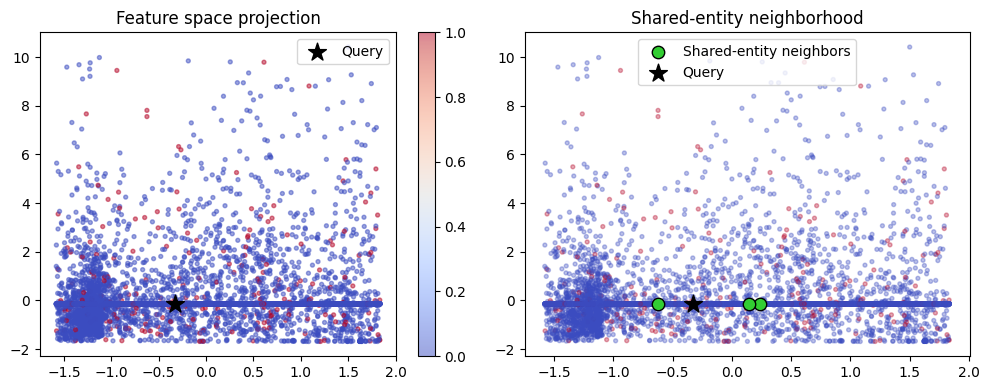

In [14]:
# Optional: quick 2D visualization of shared-entity neighborhood around one fraud sample
plot_n = min(12000, len(x_np))
fraud_positions = np.flatnonzero(y_np[:plot_n] == 1)
if len(fraud_positions) > 0:
    q = int(np.random.choice(fraud_positions))
    neighbors = edges[1, edges[0] == q]
    neighbors = neighbors[neighbors < plot_n][:200]

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sc = plt.scatter(
        x_np[:plot_n, 0], x_np[:plot_n, 1],
        c=y_np[:plot_n], s=8, alpha=0.5, cmap='coolwarm'
    )
    plt.scatter(x_np[q, 0], x_np[q, 1], color='black', marker='*', s=180, label='Query')
    plt.title('Feature space projection')
    plt.legend()
    plt.colorbar(sc)

    plt.subplot(1, 2, 2)
    plt.scatter(
        x_np[:plot_n, 0], x_np[:plot_n, 1],
        c=y_np[:plot_n], s=8, alpha=0.35, cmap='coolwarm'
    )
    plt.scatter(
        x_np[neighbors, 0], x_np[neighbors, 1],
        color='limegreen', edgecolors='black', s=80, label='Shared-entity neighbors'
    )
    plt.scatter(x_np[q, 0], x_np[q, 1], color='black', marker='*', s=180, label='Query')
    plt.title('Shared-entity neighborhood')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No fraud samples found in plotted subset; skip plot.')

## Step 8: Build normalized adjacency for GCN

We compute:

$$\hat{A} = D^{-1/2}(A + I)D^{-1/2}$$

where $I$ adds self-loops.

In [ ]:
def normalized_adjacency(num_nodes: int, edge_index: np.ndarray) -> torch.Tensor:
    row, col = edge_index
    all_row = np.concatenate([row, np.arange(num_nodes, dtype=np.int64)])
    all_col = np.concatenate([col, np.arange(num_nodes, dtype=np.int64)])

    idx = torch.from_numpy(np.vstack([all_row, all_col]).astype(np.int64))
    vals = torch.from_numpy(np.ones(len(all_row), dtype=np.float32))
    a = torch.sparse_coo_tensor(idx, vals, size=(num_nodes, num_nodes)).coalesce()

    deg = torch.sparse.sum(a, dim=1).to_dense()
    deg_inv_sqrt = torch.pow(deg, -0.5)
    deg_inv_sqrt[torch.isinf(deg_inv_sqrt)] = 0.0

    i = a.indices()
    v = a.values() * deg_inv_sqrt[i[0]] * deg_inv_sqrt[i[1]]
    return torch.sparse_coo_tensor(i, v, a.size()).coalesce()


a_hat = normalized_adjacency(num_nodes=len(y_np), edge_index=edges)
print(a_hat)

## Step 9: Define a simple GCN-style model

In [ ]:
class SimpleGCN(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int = 64, dropout: float = 0.2):
        super().__init__()
        self.lin1 = nn.Linear(in_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, 1)
        self.dropout = dropout

    def forward(self, x: torch.Tensor, a_hat: torch.Tensor) -> torch.Tensor:
        h = torch.sparse.mm(a_hat, x)
        h = self.lin1(h)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = torch.sparse.mm(a_hat, h)
        logits = self.lin2(h).squeeze(1)
        return logits

## Step 10: Build train/validation/test masks

Split ratio is 70/15/15 with stratification.

In [ ]:
def build_masks(y: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    idx = np.arange(len(y))
    train_idx, temp_idx, y_train, y_temp = train_test_split(
        idx, y, test_size=0.30, random_state=SEED, stratify=y
    )
    val_idx, test_idx, _, _ = train_test_split(
        temp_idx, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
    )

    train_mask = np.zeros(len(y), dtype=bool)
    val_mask = np.zeros(len(y), dtype=bool)
    test_mask = np.zeros(len(y), dtype=bool)

    train_mask[train_idx] = True
    val_mask[val_idx] = True
    test_mask[test_idx] = True
    return train_mask, val_mask, test_mask


train_mask, val_mask, test_mask = build_masks(y_np)
print(f'Train/Val/Test sizes: {train_mask.sum()}/{val_mask.sum()}/{test_mask.sum()}')

## Step 11: Train the model

We use `BCEWithLogitsLoss` with positive class weighting because fraud is rare.

In [ ]:
def safe_roc_auc(y_true: np.ndarray, scores: np.ndarray) -> float:
    if len(np.unique(y_true)) < 2:
        return float('nan')
    return float(roc_auc_score(y_true, scores))


x_t = torch.from_numpy(x_np)
y_t = torch.from_numpy(y_np).float()
train_mask_t = torch.from_numpy(train_mask)
val_mask_t = torch.from_numpy(val_mask)
test_mask_t = torch.from_numpy(test_mask)

model = SimpleGCN(in_dim=x_t.shape[1], hidden_dim=HIDDEN_DIM, dropout=DROPOUT)
opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

pos = max(int(y_np.sum()), 1)
neg = max(len(y_np) - pos, 1)
pos_weight = torch.tensor([neg / pos], dtype=torch.float32)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(f'Using pos_weight={pos_weight.item():.2f}')

history = []
for epoch in range(1, EPOCHS + 1):
    model.train()
    opt.zero_grad()
    logits = model(x_t, a_hat)
    loss = criterion(logits[train_mask_t], y_t[train_mask_t])
    loss.backward()
    opt.step()

    model.eval()
    with torch.no_grad():
        val_probs = torch.sigmoid(logits[val_mask_t]).cpu().numpy()
        val_auc = safe_roc_auc(y_np[val_mask], val_probs)

    history.append((epoch, float(loss.item()), float(val_auc)))

    if epoch == 1 or epoch % LOG_EVERY == 0 or epoch == EPOCHS:
        print(f'epoch={epoch:03d} loss={loss.item():.4f} val_auc={val_auc:.4f}')

In [ ]:
# Step 12: Final test evaluation
model.eval()
with torch.no_grad():
    final_logits = model(x_t, a_hat)
    test_probs = torch.sigmoid(final_logits[test_mask_t]).cpu().numpy()

test_y = y_np[test_mask]
test_auc = safe_roc_auc(test_y, test_probs)
test_pr_auc = average_precision_score(test_y, test_probs)

print('[results]')
print(f'test_roc_auc={test_auc:.4f}')
print(f'test_pr_auc={test_pr_auc:.4f}')

In [ ]:
# Step 13: Visualize learning curves
history_df = pd.DataFrame(history, columns=['epoch', 'loss', 'val_auc'])

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_df['epoch'], history_df['loss'])
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(history_df['epoch'], history_df['val_auc'])
plt.title('Validation ROC-AUC')
plt.xlabel('Epoch')
plt.ylabel('ROC-AUC')
plt.tight_layout()
plt.show()

history_df.tail(10)

## Step 14: Suggested experiments

Try one change at a time and track test ROC-AUC and PR-AUC:
1. Increase `MAX_ROWS` (if memory allows)
2. Increase `MAX_FEATURES`
3. Increase `K_NEIGHBORS` from 8 to 12
4. Increase `HIDDEN_DIM` from 64 to 128
5. Train longer with `EPOCHS = 50`

This baseline is intentionally simple so you can iterate quickly and understand each step.